# 04b — ViT 3-Class Retraining on OASIS
### NeuroReach | Mohina Rustamova
**Goal:** Retrain ViT-B/16 on OASIS with 3 classes (CN, MCI, AD) to match ADNI label space.
- Drop Moderate Dementia (no ADNI equivalent)
- Remap: Non Demented→CN(0), Very Mild→MCI(1), Mild→AD(2)
- Save weights to Google Drive

In [1]:
# ============================================================
# Cell 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/NeuroReach', exist_ok=True)
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


In [2]:
# ============================================================
# Cell 2 — Setup Kaggle API
# ============================================================
from google.colab import files
print('Upload your kaggle.json:')
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle API configured.')

Upload your kaggle.json:


Saving kaggle.json to kaggle.json
Kaggle API configured.


In [3]:
# ============================================================
# Cell 3 — Install Dependencies + Imports
# ============================================================
!pip install timm -q

import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split, Dataset, Subset
from torchvision import transforms, datasets
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [4]:
# ============================================================
# Cell 4 — Download OASIS Dataset
# ============================================================
!kaggle datasets download -d ninadaithal/imagesoasis -p /content/oasis --unzip
print('OASIS downloaded.')

# Find data path
for root, dirs, files_list in os.walk('/content/oasis'):
    for d in dirs:
        print(os.path.join(root, d))
    break

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:11<00:00, 116MB/s]

OASIS downloaded.
/content/oasis/Data


In [5]:
# ============================================================
# Cell 5 — Build 3-Class OASIS Dataset
# ============================================================
# OASIS original classes (alphabetical order from ImageFolder):
#   0: Mild Dementia      → AD (2)
#   1: Moderate Dementia  → DROP
#   2: Non Demented       → CN (0)
#   3: Very mild Dementia → MCI (1)
#
# We filter out Moderate Dementia and remap remaining 3 classes.

DATA_DIR  = '/content/oasis/Data'
IMG_SIZE  = 224
BATCH_SIZE = 32

# OASIS class index → new 3-class index
# Moderate Dementia (index 1) is excluded
LABEL_MAP = {
    0: 2,   # Mild Dementia      → AD
    # 1: excluded (Moderate Dementia)
    2: 0,   # Non Demented       → CN
    3: 1,   # Very mild Dementia → MCI
}
CLASS_NAMES_3 = ['CN (Non Demented)', 'MCI (Very Mild)', 'AD (Mild Dementia)']

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(root=DATA_DIR)
print(f'Original classes: {full_dataset.classes}')
print(f'Total images: {len(full_dataset)}')

# Filter out Moderate Dementia (class index 1) and remap labels
class ThreeClassDataset(Dataset):
    def __init__(self, dataset, label_map, transform=None):
        self.transform = transform
        self.samples = []
        for path, label in dataset.samples:
            if label in label_map:
                self.samples.append((path, label_map[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        from PIL import Image
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Build train and val/test datasets
train_dataset_full = ThreeClassDataset(full_dataset, LABEL_MAP, transform=train_transforms)
valtest_dataset    = ThreeClassDataset(full_dataset, LABEL_MAP, transform=val_test_transforms)

total = len(train_dataset_full)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

# Use same indices for all splits
indices = list(range(total))
torch.manual_seed(42)
train_indices, val_indices, test_indices = torch.utils.data.random_split(
    indices, [train_size, val_size, test_size]
)

from torch.utils.data import Subset
train_set = Subset(train_dataset_full, train_indices)
val_set   = Subset(valtest_dataset,    val_indices)
test_set  = Subset(valtest_dataset,    test_indices)

# Weighted sampler for class imbalance
train_labels  = [train_dataset_full.samples[i][1] for i in train_indices]
class_counts  = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f'3-class dataset: {total} images (Moderate Dementia dropped)')
print(f'Train: {train_size} | Val: {val_size} | Test: {test_size}')
print(f'Class distribution: {dict(zip(CLASS_NAMES_3, class_counts))}')

Original classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Total images: 86437
3-class dataset: 85949 images (Moderate Dementia dropped)
Train: 60164 | Val: 12892 | Test: 12893
Class distribution: {'CN (Non Demented)': np.int64(47130), 'MCI (Very Mild)': np.int64(9575), 'AD (Mild Dementia)': np.int64(3459)}


In [6]:
# ============================================================
# Cell 6 — Build ViT-B/16 (3-class head)
# ============================================================

NUM_CLASSES = 3

model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
model = model.to(device)

# Freeze all except last 2 blocks + head (same as notebook 04)
for param in model.parameters():
    param.requires_grad = False
for block in model.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True
for param in model.head.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=10)
print(f'Optimizer: Adam | LR: 2e-5')
print(f'Scheduler: CosineAnnealingLR | T_max: 10')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total parameters    : 85,800,963
Trainable parameters: 14,178,051
Optimizer: Adam | LR: 2e-5
Scheduler: CosineAnnealingLR | T_max: 10


In [7]:
# ============================================================
# Cell 7 — Training Loop
# ============================================================

EPOCHS = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        train_correct += (preds == lbls).sum().item()
        train_total += lbls.size(0)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == lbls).sum().item()
            val_total += lbls.size(0)

    train_acc = train_correct / train_total * 100
    val_acc   = val_correct / val_total * 100
    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    scheduler.step()

    print(f'Epoch [{epoch+1}/{EPOCHS}] '
          f'Train Loss: {train_loss/len(train_loader):.4f} | '
          f'Train Acc: {train_acc:.2f}% | '
          f'Val Acc: {val_acc:.2f}%')

Epoch [1/10] Train Loss: 0.4207 | Train Acc: 82.22% | Val Acc: 90.24%
Epoch [2/10] Train Loss: 0.1381 | Train Acc: 94.84% | Val Acc: 95.70%
Epoch [3/10] Train Loss: 0.0737 | Train Acc: 97.32% | Val Acc: 97.98%
Epoch [4/10] Train Loss: 0.0474 | Train Acc: 98.34% | Val Acc: 98.77%
Epoch [5/10] Train Loss: 0.0289 | Train Acc: 98.97% | Val Acc: 98.95%
Epoch [6/10] Train Loss: 0.0195 | Train Acc: 99.33% | Val Acc: 99.28%
Epoch [7/10] Train Loss: 0.0111 | Train Acc: 99.62% | Val Acc: 99.67%
Epoch [8/10] Train Loss: 0.0090 | Train Acc: 99.70% | Val Acc: 99.68%
Epoch [9/10] Train Loss: 0.0055 | Train Acc: 99.83% | Val Acc: 99.71%
Epoch [10/10] Train Loss: 0.0050 | Train Acc: 99.85% | Val Acc: 99.83%


=== ViT 3-Class on OASIS Test Set ===
Accuracy: 99.85%
                    precision    recall  f1-score   support

 CN (Non Demented)       1.00      1.00      1.00     10010
   MCI (Very Mild)       0.99      1.00      1.00      2118
AD (Mild Dementia)       0.99      1.00      1.00       765

          accuracy                           1.00     12893
         macro avg       1.00      1.00      1.00     12893
      weighted avg       1.00      1.00      1.00     12893



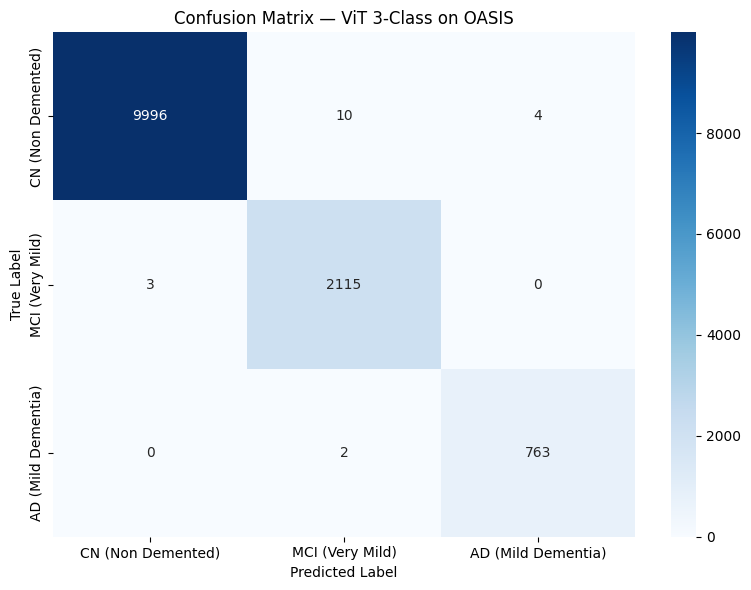

In [8]:
# ============================================================
# Cell 8 — Evaluate on Test Set
# ============================================================

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())

acc = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
print(f'=== ViT 3-Class on OASIS Test Set ===')
print(f'Accuracy: {acc:.2f}%')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES_3))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES_3, yticklabels=CLASS_NAMES_3)
plt.title('Confusion Matrix — ViT 3-Class on OASIS')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NeuroReach/vit_3class_confusion_matrix.png', dpi=150)
plt.show()

In [9]:
# ============================================================
# Cell 9 — Save Weights to Google Drive
# ============================================================

SAVE_PATH = '/content/drive/MyDrive/NeuroReach/vit_3class_oasis.pth'
torch.save(model.state_dict(), SAVE_PATH)
print(f'ViT 3-class weights saved to: {SAVE_PATH}')
print('Done! Use these weights for CORAL and ADNI fine-tuning.')

ViT 3-class weights saved to: /content/drive/MyDrive/NeuroReach/vit_3class_oasis.pth
Done! Use these weights for CORAL and ADNI fine-tuning.
